In [1]:
import zipfile
import os

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("fake_news_data")

print("Files extracted:")
print(os.listdir("fake_news_data"))

Files extracted:
['Fake.csv', 'True.csv']


In [2]:
import pandas as pd

fake = pd.read_csv("fake_news_data/Fake.csv")
true = pd.read_csv("fake_news_data/True.csv")

print("Fake news shape:", fake.shape)
print("Real news shape:", true.shape)

print("\nFake news:")
display(fake.head())

print("\nReal news:")
display(true.head())

Fake news shape: (23481, 4)
Real news shape: (21417, 4)

Fake news:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"



Real news:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [3]:
fake['label'] = 1
true['label'] = 0

data = pd.concat([fake, true], ignore_index=True)

print("Combined dataset shape:", data.shape)
print("\nClass distribution:")
print(data['label'].value_counts())

display(data.head())

Combined dataset shape: (44898, 5)

Class distribution:
label
1    23481
0    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [4]:
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset shuffled successfully.")
display(data[['title', 'label']].head(10))

Dataset shuffled successfully.


,title,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,1
1,Trump drops Steve Bannon from National Securit...,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,0
3,OOPS: Trump Just Accidentally Confirmed He Le...,1
4,Donald Trump heads for Scotland to reopen a go...,0
5,Paul Ryan Responds To Dem’s Sit-In On Gun Con...,1
6,AWESOME! DIAMOND AND SILK Rip Into The Press: ...,1
7,STAND UP AND CHEER! UKIP Party Leader SLAMS Ge...,1
8,North Korea shows no sign it is serious about ...,0
9,Trump signals willingness to raise U.S. minimu...,0


In [5]:
data['content'] = data['title'].fillna('') + ' ' + data['text'].fillna('')

print("Content column created.")
display(data[['content', 'label']].head())

Content column created.


,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,1
1,Trump drops Steve Bannon from National Securit...,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,0
3,OOPS: Trump Just Accidentally Confirmed He Le...,1
4,Donald Trump heads for Scotland to reopen a go...,0


In [6]:
from sklearn.model_selection import train_test_split

X = data['content']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 35918
Testing samples: 8980


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_df=0.7,
    max_features=50000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (35918, 50000)
Testing TF-IDF shape: (8980, 50000)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9868596881959911

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4284
           1       0.99      0.98      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



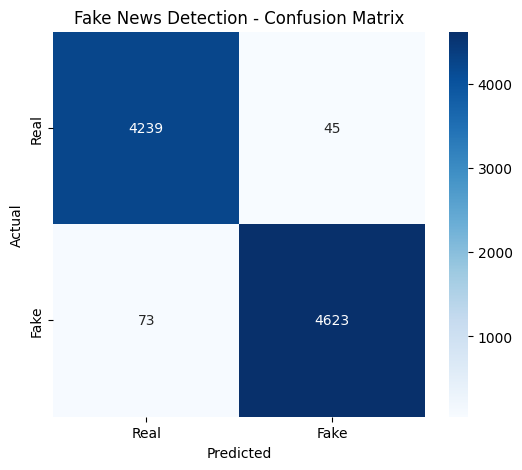

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Fake News Detection - Confusion Matrix')
plt.show()

In [10]:
def predict_news(news_text):
    news_tfidf = tfidf.transform([news_text])
    prediction = model.predict(news_tfidf)[0]
    probability = model.predict_proba(news_tfidf)[0].max()

    if prediction == 1:
        result = "FAKE NEWS"
    else:
        result = "REAL NEWS"

    print("Prediction:", result)
    print("Confidence:", f"{probability * 100:.2f}%")

    return result


# Example
sample_news = """
The government announced a new policy that will provide financial
support to students pursuing higher education.
"""

predict_news(sample_news)

Prediction: REAL NEWS
Confidence: 54.29%


'REAL NEWS'

In [11]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("Linear SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

Linear SVM Accuracy: 0.99543429844098

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4284
           1       1.00      0.99      1.00      4696

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [12]:
logistic_accuracy = accuracy_score(y_test, y_pred)
svm_accuracy = accuracy_score(y_test, svm_pred)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVM'],
    'Accuracy': [logistic_accuracy, svm_accuracy]
})

comparison['Accuracy (%)'] = comparison['Accuracy'] * 100

display(comparison[['Model', 'Accuracy (%)']])

,Model,Accuracy (%)
0,Logistic Regression,98.685969
1,Linear SVM,99.543430


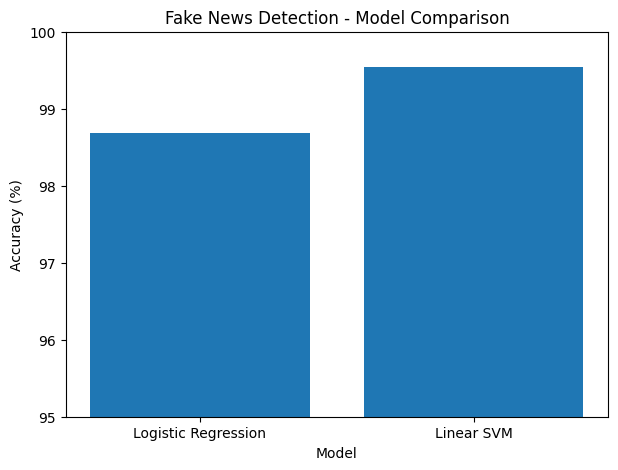

In [13]:
plt.figure(figsize=(7, 5))

plt.bar(comparison['Model'], comparison['Accuracy (%)'])

plt.ylabel('Accuracy (%)')
plt.xlabel('Model')
plt.title('Fake News Detection - Model Comparison')
plt.ylim(95, 100)

plt.show()

In [14]:
def predict_news_svm(news_text):
    news_tfidf = tfidf.transform([news_text])
    prediction = svm_model.predict(news_tfidf)[0]

    if prediction == 1:
        result = "FAKE NEWS"
    else:
        result = "REAL NEWS"

    print("Prediction:", result)

    return result


# Test example
sample_news = """
The government announced a new education policy that will provide
financial support to students pursuing higher education.
"""

predict_news_svm(sample_news)

Prediction: FAKE NEWS


'FAKE NEWS'

In [15]:
test_news = [
    "The central bank announced a change in interest rates following its latest policy meeting.",

    "Scientists have discovered that drinking a special magical drink can make humans live for 200 years.",

    "The government announced a new public transportation project that will connect several major cities."
]

for news in test_news:
    print("\nNews:", news)
    predict_news_svm(news)


News: The central bank announced a change in interest rates following its latest policy meeting.
Prediction: REAL NEWS

News: Scientists have discovered that drinking a special magical drink can make humans live for 200 years.
Prediction: FAKE NEWS

News: The government announced a new public transportation project that will connect several major cities.
Prediction: FAKE NEWS


## Results and Model Comparison

Two machine learning models were evaluated for fake news classification.

| Model | Accuracy |
|---|---:|
| Logistic Regression | 98.69% |
| Linear SVM | 99.54% |

The Linear SVM achieved the best accuracy of **99.54%** on the test dataset and was selected as the final prediction model.

### Key Techniques Used

- Text preprocessing and dataset preparation
- TF-IDF vectorization
- Logistic Regression
- Linear Support Vector Machine (SVM)
- Train-test splitting with stratification
- Classification report
- Confusion matrix
- Model comparison
- Custom news prediction function

### Important Limitation

This project performs **text-based classification** using patterns learned from the training dataset. It does not independently verify news against external sources or determine whether a claim is factually true.

## Conclusion

This project demonstrates how Natural Language Processing and machine learning can be used to classify news articles as real or fake.

TF-IDF was used to convert news text into numerical features, while Logistic Regression and Linear SVM were trained for classification. Linear SVM achieved the highest test accuracy of 99.54%.

The project also includes a prediction function that allows new news text to be classified using the trained model.